In [13]:
import numpy as np

fname = "fss_merged.npz"

# npzファイルを開く
data = np.load(fname)

# キー一覧を表示
print("keys:", data.files)

# 各キーの shape や dtype を確認
for k in data.files:
    arr = data[k]
    #print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")

# 例えば pg をちょっと見る
print("pg =", data["pg"][:21])
print("TEE1_size =", data["TEE6_size"])
print("TEE1_var =", data["TEE6_ave"][:21])
print("TEE1_ave_err =", data["TEE6_ave_err"][:21])
print("TEE1_var =", data["TEE6_var"][:21])
print("TEE1_var_err =", data["TEE6_var_err"][:21])

keys: ['pg', 'TEE1_size', 'TEE1_ave', 'TEE1_ave_err', 'TEE1_var', 'TEE1_var_err', 'TEE2_size', 'TEE2_ave', 'TEE2_ave_err', 'TEE2_var', 'TEE2_var_err', 'TEE3_size', 'TEE3_ave', 'TEE3_ave_err', 'TEE3_var', 'TEE3_var_err', 'TEE4_size', 'TEE4_ave', 'TEE4_ave_err', 'TEE4_var', 'TEE4_var_err', 'TEE5_size', 'TEE5_ave', 'TEE5_ave_err', 'TEE5_var', 'TEE5_var_err', 'TEE6_size', 'TEE6_ave', 'TEE6_ave_err', 'TEE6_var', 'TEE6_var_err']
pg = [0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9 ]
TEE1_size = 6.0
TEE1_var = [ 0.04563889  0.05750694  0.06554861  0.07935069  0.09141667  0.10918403
  0.13122917  0.1480625   0.16312153  0.14836806  0.09855903 -0.02998611
 -0.22179167 -0.401      -0.54650347 -0.66287153 -0.74336806 -0.80841319
 -0.85748958 -0.9006875  -0.92683333]
TEE1_ave_err = [0.00148967 0.00173158 0.00188345 0.00214285 0.00234856 0.0026852
 0.00300376 0.00314851 0.00358927 0.00374174 0.00474577 0.00588672
 0.00664999 0.00577886 0.005

=== zeta from peak-height scaling (bootstrap) ===
mode(L_eff) = sqrtAh, SERIES = ['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']
TEE2: L_eff= 6.000 | peak=0.0078575 ± 0.00035 | g*≈0.79569 ± 0.00575
TEE3: L_eff= 7.348 | peak=0.0109716 ± 0.00059 | g*≈0.80833 ± 0.00373
TEE4: L_eff= 8.485 | peak=0.0137507 ± 0.00072 | g*≈0.81239 ± 0.00426
TEE5: L_eff= 9.487 | peak=0.0170977 ± 0.00098 | g*≈0.81785 ± 0.00411
TEE6: L_eff=10.392 | peak=0.0221359 ± 0.0014 | g*≈0.82000 ± 0.00032

ζ = 1.826327 ± 0.123121


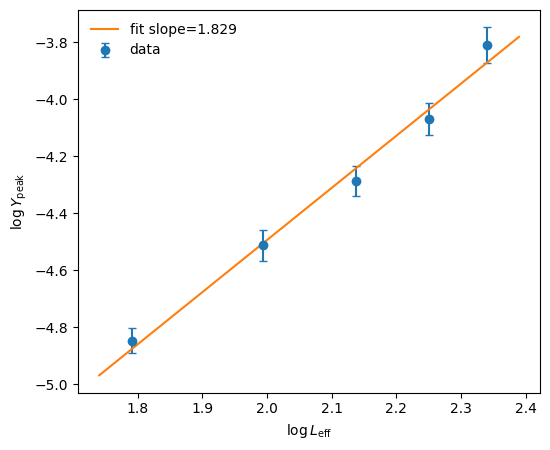

In [29]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import re
import numpy as np
import matplotlib.pyplot as plt

# ========= 設定 =========
NPZ_PATH = "fss_merged.npz"
# 使う系列（npz に存在するキーから自動検出されるが、順序制御したい時は明示）
SERIES_KEYS = ["TEE2","TEE3","TEE4","TEE5","TEE6"]

# 有効サイズ（Ah or sqrtAh）
EFF_SIZE_MODE = "sqrtAh"   # "sqrtAh"（推奨） / "Ah" / "size"（_size が npz にある場合に利用）
AH_MAP = {"TEE2":36, "TEE3":54, "TEE4":72, "TEE5":90, "TEE6":108}
#AH_MAP = {"TEE1":6, "TEE2":12, "TEE3":18, "TEE4":24, "TEE5":30, "TEE6":36}
    
# ピーク抽出のブートストラップ回数
N_BOOT_PEAK = 2000
# ζ のモンテカルロ回数
N_BOOT_ZETA = 5000
RNG = np.random.default_rng(0)

# p 窓（必要なら有効化）
# PG_WINDOW = (0.78, 0.90)
PG_WINDOW = None  # or (0.78, 0.90)

# ========= ユーティリティ =========
def eff_size_from_keys(keys, dat=None, mode="sqrtAh"):
    """keysごとの有効サイズを返す。mode='size' は npz 内の '{key}_size' を優先的に使う。"""
    Leff = []
    for k in keys:
        if mode == "size":
            skey = f"{k}_size"
            if dat is not None and skey in dat:
                v = dat[skey]
                v = float(v if np.isscalar(v) else np.array(v).reshape(-1)[0])
                Leff.append(v); continue
            # size が無い場合は AH_MAP にフォールバック
        if k not in AH_MAP:
            # AH_MAP が無ければ “キー中の番号” で単調性だけ担保（例: TEE12→12）
            m = re.match(r"TEE(\d+)", k)
            Leff.append(float(m.group(1)) if m else np.nan)
            continue
        Ah = float(AH_MAP[k])
        if mode == "Ah":
            Leff.append(Ah)
        elif mode == "sqrtAh":
            Leff.append(np.sqrt(Ah))
        else:
            raise ValueError("EFF_SIZE_MODE must be 'Ah', 'sqrtAh', or 'size'.")
    return np.asarray(Leff, dtype=float)

def peak_bootstrap(g, y, yerr, nboot=1000, rng=None):
    if rng is None: rng = np.random.default_rng()
    yerr = np.where(np.isfinite(yerr) & (yerr>0), yerr, max(1e-12, np.nanmedian(np.abs(y))*1e-6))
    peaks, peak_pos = [], []
    for _ in range(nboot):
        yb = y + rng.normal(0.0, yerr)
        i  = int(np.nanargmax(yb))
        peaks.append(max(yb[i], 1e-16))
        peak_pos.append(g[i])
    peaks = np.asarray(peaks); peak_pos = np.asarray(peak_pos)
    return peaks.mean(), peaks.std(ddof=1), peak_pos.mean(), peak_pos.std(ddof=1)

def zeta_from_loglog_mc(L_eff, Y_mean, Y_se, nboot=5000, rng=None):
    if rng is None: rng = np.random.default_rng()
    x = np.log(L_eff)
    zetas = []
    for _ in range(nboot):
        ys = np.maximum(rng.normal(Y_mean, Y_se), 1e-16)
        y = np.log(ys)
        coef = np.polyfit(x, y, deg=1)
        zetas.append(coef[0])
    z = np.asarray(zetas)
    return z.mean(), z.std(ddof=1)

# ========= データ読み込み =========
dat = np.load(NPZ_PATH, allow_pickle=True)
g = np.array(dat["pg"], dtype=float)

# 利用可能なシリーズを npz から安全に抽出
all_series = sorted({ m.group(1) for k in dat.keys()
                      for m in [re.match(r'^(TEE\d+)_', k)] if m })
# 指定がなければ自動検出を使う
if not SERIES_KEYS:
    SERIES_KEYS = all_series
else:
    # 指定のうち実在するものに限定
    SERIES_KEYS = [s for s in SERIES_KEYS if any(k.startswith(s+"_") for k in dat.keys())]

# エラーキー名（ *_var_err または *_err ）を自動判定
def resolve_err_key(prefix: str) -> str:
    if f"{prefix}_var_err" in dat: return f"{prefix}_var_err"
    if f"{prefix}_err"     in dat: return f"{prefix}_err"
    raise KeyError(f"{prefix} の誤差キー (_var_err か _err) が見つかりません")

# ========= 各サイズのピーク抽出 =========
peak_means, peak_ses, peak_pos_mean, peak_pos_se = [], [], [], []
used_series = []

for key in SERIES_KEYS:
    ykey  = f"{key}_var"
    dykey = resolve_err_key(key)
    if ykey not in dat:
        # たとえば “_var”が無い場合は “_ave_var”等、命名違いに合わせてここで分岐させてもOK
        raise KeyError(f"{ykey} が npz にありません")

    y  = np.asarray(dat[ykey],  dtype=float)
    dy = np.asarray(dat[dykey], dtype=float)

    # p 窓で切る
    if PG_WINDOW is not None:
        lo, hi = PG_WINDOW
        mask = (g >= lo) & (g <= hi)
        if mask.sum() < 3:
            # 窓が狭すぎる場合は自動的に全域
            g_use, y_use, dy_use = g, y, dy
        else:
            g_use, y_use, dy_use = g[mask], y[mask], dy[mask]
    else:
        g_use, y_use, dy_use = g, y, dy

    mu, se, gx, gs = peak_bootstrap(g_use, y_use, dy_use, nboot=N_BOOT_PEAK, rng=RNG)
    peak_means.append(mu); peak_ses.append(se)
    peak_pos_mean.append(gx); peak_pos_se.append(gs)
    used_series.append(key)

peak_means    = np.asarray(peak_means)
peak_ses      = np.asarray(peak_ses)
peak_pos_mean = np.asarray(peak_pos_mean)
peak_pos_se   = np.asarray(peak_pos_se)

# ========= 有効サイズ配列 =========
# ※ EFF_SIZE_MODE="size" なら npz の {key}_size を優先
L_eff = eff_size_from_keys(used_series, dat=dat, mode=EFF_SIZE_MODE)

# ========= ζ 推定 =========
zeta_mean, zeta_std = zeta_from_loglog_mc(L_eff, peak_means, peak_ses,
                                          nboot=N_BOOT_ZETA, rng=RNG)

print("=== zeta from peak-height scaling (bootstrap) ===")
print(f"mode(L_eff) = {EFF_SIZE_MODE}, SERIES = {used_series}")
for k, Le, mu, se, gx, gs in zip(used_series, L_eff, peak_means, peak_ses, peak_pos_mean, peak_pos_se):
    print(f"{k:>4s}: L_eff={Le:>6.3f} | peak={mu:.6g} ± {se:.2g} | g*≈{gx:.5f} ± {gs:.5f}")
print(f"\nζ = {zeta_mean:.6f} ± {zeta_std:.6f}")

# ========= 可視化（log–log） =========
fig, ax = plt.subplots(figsize=(5.6,4.6))
# 誤差は d(logY) ≈ dY/Y
ax.errorbar(np.log(L_eff), np.log(peak_means),
            yerr=peak_ses/np.maximum(peak_means, 1e-16),
            fmt='o', capsize=3, label="data")

coef = np.polyfit(np.log(L_eff), np.log(peak_means), deg=1)
xx = np.linspace(np.log(L_eff.min()*0.95), np.log(L_eff.max()*1.05), 100)
yy = np.polyval(coef, xx)
ax.plot(xx, yy, '-', label=f"fit slope={coef[0]:.3f}")

ax.set_xlabel(r"$\log L_{\rm eff}$")
ax.set_ylabel(r"$\log Y_{\rm peak}$")
ax.legend(frameon=False)
ax.grid(False)
fig.tight_layout()
fig.savefig("zeta_peakheight_loglog.png", dpi=300, bbox_inches="tight")
plt.show()


[info] zeta = 1.6098  (mode=fit)
[drift-fit] pc=0.852092, nu=0.9558


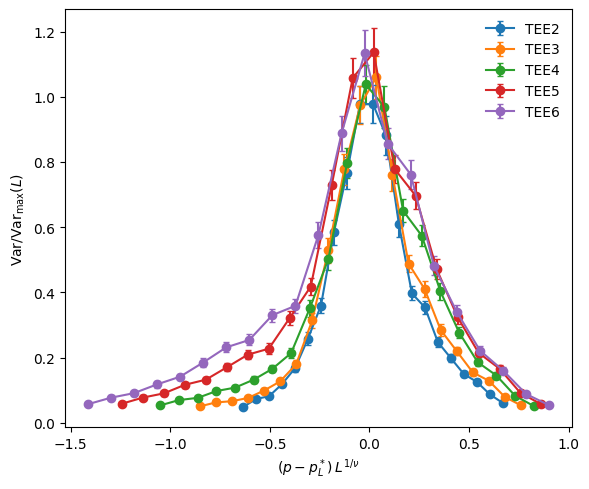

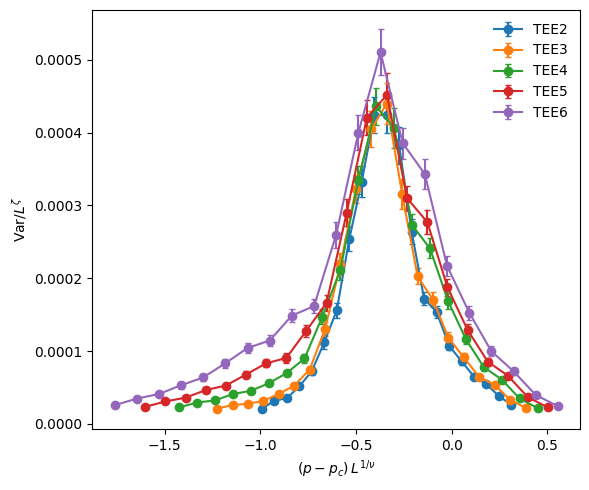


=== summary ===
TEE2: L_eff= 6.000 | g*≈0.797335 | Var_max≈0.00775977
TEE3: L_eff= 7.348 | g*≈0.805670 | Var_max≈0.0102894
TEE4: L_eff= 8.485 | g*≈0.811970 | Var_max≈0.0131253
TEE5: L_eff= 9.487 | g*≈0.817990 | Var_max≈0.0148793
TEE6: L_eff=10.392 | g*≈0.822092 | Var_max≈0.0195155
zeta=1.6098, pc=0.852092, nu=0.9558, window S=2.0


In [39]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

##########################################
#    code 1
##########################################

import re, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ========= 設定 =========
NPZ_PATH = "fss_merged.npz"
SERIES_KEYS = ["TEE2","TEE3","TEE4","TEE5","TEE6"]        # 使う系列
AH_MAP_NUM = {"TEE2":36, "TEE3":54, "TEE4":72, "TEE5":90, "TEE6":108}  # ← 指定どおり
EFF_SIZE_MODE = "sqrtAh"                                   # L=√Ah で固定
PG_WINDOW = None                                           # 例: (0.76,0.86) で左右対称に
EXCLUDE_SERIES = set()                                     # 例: {"TEE2"}
ZETA_MODE  = "fit"                                         # "fit" or "fixed"
ZETA_FIXED = 1.8
S_WINDOW = 2.0                                             # collapse の |x| 窓
SAVE_PREFIX = "collapse_np"                                # 出力ファイル名プレフィックス
RNG = np.random.default_rng(0)

# collapse フォールバック探索域（pgに合わせ動的に後で調整）
PC_GRID_N = 61
NU_GRID   = np.linspace(0.9, 2.2, 66)

# ========= ユーティリティ =========
def eff_size(keys):
    L=[]
    for k in keys:
        Ah = AH_MAP_NUM.get(k, None)
        if Ah is None: 
            m=re.match(r"TEE(\d+)", k); L.append(float(m.group(1)) if m else np.nan); continue
        L.append(np.sqrt(float(Ah)))  # L=√Ah 固定
    return np.asarray(L, float)

def resolve_err_key(prefix, dat):
    if f"{prefix}_var_err" in dat: return f"{prefix}_var_err"
    if f"{prefix}_err"     in dat: return f"{prefix}_err"
    raise KeyError(f"{prefix}: _var_err/_err がありません")

def quad(x,a,b,c): return a*x**2 + b*x + c

def peak_parabola(pg, y, dy):
    """ピーク位置gxと高さyp（誤差は必要最小限で安全側）"""
    eps = max(1e-12, np.nanmedian(np.abs(y))*1e-6 if np.isfinite(y).any() else 1e-8)
    dy = np.where(np.isfinite(dy)&(dy>0), dy, eps)
    imax = int(np.nanargmax(y))
    lo,hi = max(0,imax-2), min(len(pg), imax+3)
    x, yy, dyy = pg[lo:hi], y[lo:hi], dy[lo:hi]
    if x.size < 3:
        return float(pg[imax]), float(y[imax]), float(dy[imax])
    try:
        popt, pcov = curve_fit(quad, x, yy, sigma=dyy, absolute_sigma=True, maxfev=20000)
        a,b,c = popt
        gx = -b/(2*a)
        yp = float(quad(gx, *popt))
        if (gx < pg.min()) or (gx > pg.max()):
            return float(pg[imax]), float(y[imax]), float(dy[imax])
        dy_p = float(np.nanmin(dyy)) if np.isfinite(dyy).any() else eps
        return float(gx), max(yp,1e-16), max(dy_p,1e-12)
    except Exception:
        return float(pg[imax]), float(y[imax]), float(dy[imax])

def gstar_model(L, pc, a, invnu):
    return pc + a * L**(-invnu)

def collapse_score(pc, nu, zeta, series_used, L_eff, Y_all, pg, s_window=None):
    """y/L^zeta vs x=(p-pc)L^{1/nu} を補間し、bin内分散の重み付き平均をスコアに"""
    Xs, Ys, Ws = [], [], []
    x_min, x_max = np.inf, -np.inf
    for s, Le in zip(series_used, L_eff):
        p, y, dy = Y_all[s]
        x = (p - pc) * (Le**(1.0/nu))
        yy = y / (Le**zeta)
        dyy = dy / (Le**zeta)
        w = 1.0/np.maximum(dyy, np.nanmedian(np.abs(yy))*1e-6 + 1e-8)**2
        if s_window is not None:
            m = np.abs(x) < s_window
            x, yy, w = x[m], yy[m], w[m]
        if x.size < 3: 
            continue
        Xs.append(x); Ys.append(yy); Ws.append(w)
        x_min = min(x_min, x.min()); x_max = max(x_max, x.max())
    if not Xs: return np.inf
    grid = np.linspace(x_min, x_max, 200)
    Ygrid, Wgrid = [], []
    for x, yy, w in zip(Xs, Ys, Ws):
        yg = np.interp(grid, x, yy)
        wg = np.interp(grid, x, w)
        Ygrid.append(yg); Wgrid.append(np.maximum(wg, 0))
    Ygrid = np.stack(Ygrid, 0); Wgrid = np.stack(Wgrid, 0)
    wsum = Wgrid.sum(axis=0) + 1e-12
    ybar = (Wgrid*Ygrid).sum(axis=0)/wsum
    S = ((Wgrid * (Ygrid - ybar)**2).sum(axis=0)/wsum).mean()
    return S

# ========= 1) 読み込み & series 検出 =========
dat = np.load(NPZ_PATH, allow_pickle=True)
pg = np.asarray(dat["pg"], float)
all_series = sorted({ m.group(1) for k in dat.keys() for m in [re.match(r'^(TEE\d+)_', k)] if m })
SERIES_KEYS = [s for s in SERIES_KEYS if (s in all_series) and (s not in EXCLUDE_SERIES)]
if not SERIES_KEYS: raise RuntimeError("有効な SERIES_KEYS がありません")

# ========= 2) 各サイズのピーク位置 g* と高さ =========
gstar_mu, Vmax, Vmax_se, used = [], [], [], []
Y_all = {}
for s in SERIES_KEYS:
    ykey = f"{s}_var"; dykey = resolve_err_key(s, dat)
    y  = np.asarray(dat[ykey],  float)
    dy = np.asarray(dat[dykey], float)
    if y.shape != pg.shape:
        print(f"[skip] {s}: shape mismatch"); continue
    if PG_WINDOW:
        lo,hi = PG_WINDOW
        m = (pg>=lo)&(pg<=hi)
        gg, yy, ddy = (pg[m], y[m], dy[m]) if m.sum()>=3 else (pg,y,dy)
    else:
        gg, yy, ddy = pg, y, dy
    gx, yp, dy_p = peak_parabola(gg, yy, ddy)
    gstar_mu.append(gx); Vmax.append(max(yp,1e-16)); Vmax_se.append(max(dy_p,1e-12))
    used.append(s)
    # collapse 用に全域保持
    Y_all[s] = (pg, y, dy)

gstar_mu = np.array(gstar_mu); Vmax = np.array(Vmax); Vmax_se = np.array(Vmax_se)
L_eff = eff_size(used)

# ========= 3) ζ 推定（or 固定） =========
if ZETA_MODE == "fixed":
    zeta = float(ZETA_FIXED)
else:
    m = (Vmax>0)&np.isfinite(Vmax)&np.isfinite(L_eff)
    if m.sum() < 2: raise RuntimeError("ζ回帰に十分な点がありません")
    zeta = np.polyfit(np.log(L_eff[m]), np.log(Vmax[m]), 1)[0]
print(f"[info] zeta = {zeta:.4f}  (mode={ZETA_MODE})")

# ========= 4) pc, nu 推定：まず g* ドリフト =========
pc, nu = None, None
if len(used)>=3 and np.nanstd(gstar_mu) > 1e-3:
    pc0 = float(np.median(gstar_mu)); a0 = float(np.ptp(gstar_mu) or 0.05); invnu0 = 0.7
    pc_lo = float(np.min(gstar_mu) - 0.03); pc_hi = float(np.max(gstar_mu) + 0.03)
    bounds = ([pc_lo, -np.inf, 0.3], [pc_hi, np.inf, 3.0])
    try:
        popt, pcov = curve_fit(gstar_model, L_eff, gstar_mu, p0=[pc0,a0,invnu0],
                               bounds=bounds, maxfev=40000)
        pc_g, a_g, invnu_g = popt; nu_g = 1.0/invnu_g
        if (0.0 < pc_g < 1.0) and (0.3 < nu_g < 5.0):
            pc, nu = pc_g, nu_g
            print(f"[drift-fit] pc={pc:.6f}, nu={nu:.4f}")
        else:
            print(f"[warn] drift-fit weird (pc={pc_g:.4f}, nu={nu_g:.2f})")
    except Exception as e:
        print(f"[warn] drift-fit failed: {e}")
else:
    print("[warn] g* drift not resolvable → collapse へ")

# ========= 5) フォールバック：コラプス最小化 =========
if pc is None or nu is None:
    pmin, pmax = float(pg.min()), float(pg.max())
    PC_GRID = np.linspace(pmin+0.02*(pmax-pmin), pmax-0.02*(pmax-pmin), PC_GRID_N)
    best = (np.inf, None, None)
    for pc_try in PC_GRID:
        for nu_try in NU_GRID:
            S = collapse_score(pc_try, nu_try, zeta, used, L_eff, Y_all, pg, s_window=S_WINDOW)
            if S < best[0]:
                best = (S, pc_try, nu_try)
    Sbest, pc, nu = best
    print(f"[collapse-search] S={Sbest:.4g}, pc={pc:.6f}, nu={nu:.4f}")

# ========= 6) コラプス図 =========
# (A) ピーク正規化（ζフリー）
plt.figure(figsize=(6,5))
for s, Le, gx, V in zip(used, L_eff, gstar_mu, Vmax):
    p, y, dy = Y_all[s]
    yN, dyN = y/max(V,1e-16), dy/max(V,1e-16)
    xN = (p - gx) * (Le**(1.0/nu))
    if S_WINDOW is not None:
        m = np.abs(xN) < S_WINDOW; xN,yN,dyN = xN[m], yN[m], dyN[m]
    plt.errorbar(xN, yN, yerr=dyN, fmt='o-', capsize=2, label=s)
plt.xlabel(r"$(p-p^*_L)\,L^{1/\nu}$"); plt.ylabel(r"$\mathrm{Var}/\mathrm{Var}_{\max}(L)$")
plt.legend(frameon=False); plt.tight_layout()
plt.savefig(f"{SAVE_PREFIX}_peaknorm.png", dpi=300, bbox_inches="tight"); plt.show()

# (B) ζ使用（本番）
plt.figure(figsize=(6,5))
for s, Le in zip(used, L_eff):
    p, y, dy = Y_all[s]
    yB, dyB = y/(Le**zeta), dy/(Le**zeta)
    xB = (p - pc) * (Le**(1.0/nu))
    if S_WINDOW is not None:
        m = np.abs(xB) < S_WINDOW; xB,yB,dyB = xB[m], yB[m], dyB[m]
    plt.errorbar(xB, yB, yerr=dyB, fmt='o-', capsize=2, label=s)
plt.xlabel(r"$(p-p_c)\,L^{1/\nu}$"); plt.ylabel(r"$\mathrm{Var}/L^{\zeta}$")
plt.legend(frameon=False); plt.tight_layout()
plt.savefig(f"{SAVE_PREFIX}_powerlaw.png", dpi=300, bbox_inches="tight"); plt.show()

# ========= 7) サマリ =========
print("\n=== summary ===")
for s, Le, gx, V in zip(used, L_eff, gstar_mu, Vmax):
    print(f"{s:>4s}: L_eff={Le:6.3f} | g*≈{gx:.6f} | Var_max≈{V:.6g}")
print(f"zeta={zeta:.4f}, pc={pc:.6f}, nu={nu:.4f}, window S={S_WINDOW}")


[info] PG_WINDOW = (0.7710111533392885, 0.8510111533392886)
[info] zeta = 1.6098  (mode=fit)
[scan-fit]  pc=0.869631, nu=1.3333, chi2/pt=2.0421
[collapse score (non-pyfssa)] S=0.0000


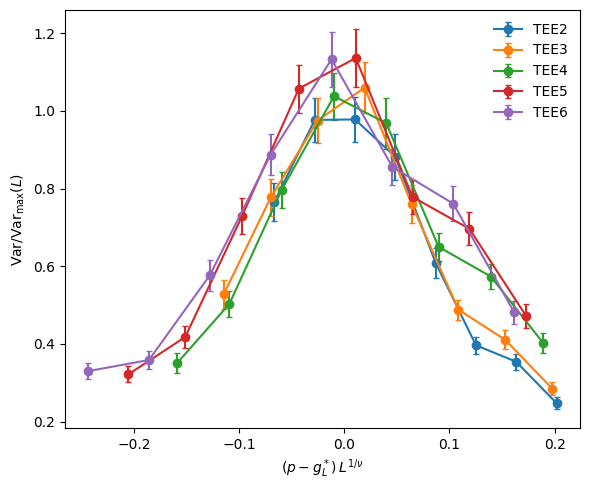

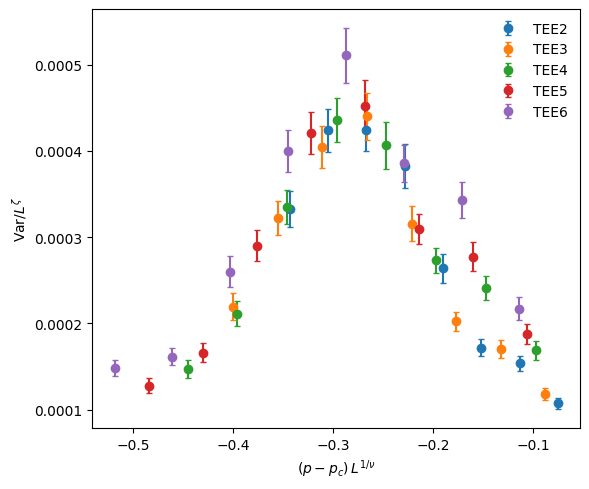


=== summary ===
TEE2: L_eff= 6.000 | g*≈0.797335 ± 0.00113 | Var_max≈0.00775977
TEE3: L_eff= 7.348 | g*≈0.805670 ± 0.00109 | Var_max≈0.0102894
TEE4: L_eff= 8.485 | g*≈0.811970 ± 0.00059 | Var_max≈0.0131253
TEE5: L_eff= 9.487 | g*≈0.817990 ± 0.00106 | Var_max≈0.0148793
TEE6: L_eff=10.392 | g*≈0.822092 ± 0.00092 | Var_max≈0.0195155
zeta=1.6098, pc=0.869631, nu=1.3333, window=(0.7710111533392885, 0.8510111533392886), S_window=2.0


In [46]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

##########################################
#    code 2
##########################################

import re, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ===================== 設定 =====================
NPZ_PATH = "fss_merged.npz"

# 使う系列（存在しないキーは自動除外）
SERIES_KEYS = ["TEE2","TEE3","TEE4","TEE5","TEE6"]

# 有効面積 Ah（あなたの指定）→ L = sqrt(Ah)
AH_MAP_NUM = {"TEE2":36, "TEE3":54, "TEE4":72, "TEE5":90, "TEE6":108}

# p 窓：AUTO で g* の平均±幅に合わせて作る。固定窓を使いたい場合は AUTO_PG_WINDOW=False にして PG_WINDOW を指定
AUTO_PG_WINDOW = True
PG_WINDOW      = (0.76, 0.86)   # AUTO=False のとき有効
AUTO_WIDTH_MIN = 0.04           # 自動窓の最小半幅（左右）

# ζ の扱い
ZETA_MODE  = "fit"              # "fit" or "fixed"
ZETA_FIXED = 1.83               # 固定するならここを使う

# g*→(pc,ν)：νを走査して線形回帰する（安定化）
#NU_SCAN = np.linspace(1.0, 2.2, 241)
NU_SCAN = np.array([4/3])  
# collapse フォールバック探索域（pc は pg の内側に）
PC_GRID_N = 61
NU_GRID_FB = np.linspace(0.9, 2.2, 66)

# collapse 図の |x| 窓
S_WINDOW = 2.0

# 小サイズが暴れる時は一時除外
EXCLUDE_SERIES = set()          # 例: {"TEE2"}

# 乱数（不要なら使われない）
RNG = np.random.default_rng(0)

# ===================== ユーティリティ =====================
def eff_size(keys):
    """L = sqrt(Ah)"""
    L=[]
    for k in keys:
        Ah = AH_MAP_NUM.get(k, None)
        if Ah is None:
            m=re.match(r"TEE(\d+)", k)
            L.append(float(m.group(1)) if m else np.nan)
        else:
            L.append(np.sqrt(float(Ah)))
    return np.asarray(L, float)

def resolve_err_key(prefix, dat):
    if f"{prefix}_var_err" in dat: return f"{prefix}_var_err"
    if f"{prefix}_err"     in dat: return f"{prefix}_err"
    raise KeyError(f"{prefix}: _var_err/_err がありません")

def quad(x,a,b,c): return a*x**2 + b*x + c

def peak_parabola(pg, y, dy):
    """
    近傍2～5点で2次フィット → 頂点位置 gx（±σ）、高さ yp（±近傍の最小誤差）
    フォールバック：グリッド最大。
    """
    pg = np.asarray(pg, float); y = np.asarray(y, float); dy = np.asarray(dy, float)
    eps = max(1e-12, np.nanmedian(np.abs(y))*1e-6 if np.isfinite(y).any() else 1e-8)
    dy = np.where(np.isfinite(dy)&(dy>0), dy, eps)
    imax = int(np.nanargmax(y))
    lo,hi = max(0,imax-2), min(len(pg), imax+3)
    x, yy, dyy = pg[lo:hi], y[lo:hi], dy[lo:hi]
    if x.size < 3:
        gx = float(pg[imax]); gx_err = (pg[min(imax+1,len(pg)-1)]-pg[max(imax-1,0)]) / np.sqrt(12)
        yp = float(y[imax]);  yp_err = float(dy[imax])
        return gx, gx_err, max(yp,1e-16), max(yp_err,1e-12)
    try:
        popt, pcov = curve_fit(quad, x, yy, sigma=dyy, absolute_sigma=True, maxfev=20000)
        a,b,c = popt
        gx = -b/(2*a)
        # Var(gx) from error propagation
        vb, va, vab = pcov[1,1], pcov[0,0], pcov[0,1]
        dg_db = -1/(2*a); dg_da =  b/(2*a*a)
        vg = dg_db**2 * vb + dg_da**2 * va + 2*dg_db*dg_da*vab
        gx_err = float(np.sqrt(abs(vg))) if np.isfinite(vg) and vg>0 else (x.ptp()/np.sqrt(12))
        yp = float(quad(gx, *popt))
        if (gx < pg.min()) or (gx > pg.max()):
            gx = float(pg[imax]); gx_err = (pg[min(imax+1,len(pg)-1)]-pg[max(imax-1,0)]) / np.sqrt(12)
            yp = float(y[imax]);  yp_err = float(dy[imax])
            return gx, gx_err, max(yp,1e-16), max(yp_err,1e-12)
        yp_err = float(np.nanmin(dyy)) if np.isfinite(dyy).any() else eps
        return float(gx), max(gx_err,1e-6), max(yp,1e-16), max(yp_err,1e-12)
    except Exception:
        gx = float(pg[imax]); gx_err = (pg[min(imax+1,len(pg)-1)]-pg[max(imax-1,0)]) / np.sqrt(12)
        yp = float(y[imax]);  yp_err = float(dy[imax])
        return gx, gx_err, max(yp,1e-16), max(yp_err,1e-12)

def gstar_model(L, pc, a, invnu):
    return pc + a * L**(-invnu)

def fit_pc_nu_by_scan(L_eff, gmu, gse, nu_grid, pc_lo=None, pc_hi=None):
    """
    各 ν について X=L^{-1/ν} を作り、y=g* を w=1/σ^2 で線形回帰: y = pc + a X。
    χ^2/N を最小にする (pc, ν) を返す。
    """
    L_eff = np.asarray(L_eff, float)
    y  = np.asarray(gmu, float)
    dy = np.asarray(gse, float)
    w  = 1.0/np.maximum(dy, np.nanmedian(np.abs(dy))*1e-6 + 1e-8)**2

    best = (np.inf, None, None)  # (chi2_per_pt, pc, nu)
    for nu_try in nu_grid:
        X = L_eff**(-1.0/nu_try)
        A = np.vstack([np.ones_like(X), X]).T
        W = np.diag(w)
        ATA = A.T @ W @ A
        ATy = A.T @ W @ y
        try:
            beta = np.linalg.solve(ATA, ATy)   # beta[0]=pc, beta[1]=a
        except np.linalg.LinAlgError:
            continue
        pc_try = float(beta[0])
        if (pc_lo is not None and pc_try < pc_lo) or (pc_hi is not None and pc_try > pc_hi):
            continue
        yfit = A @ beta
        chi2 = np.sum(w * (y - yfit)**2)
        dof  = max(1, (len(y)-2))
        chi2_per = chi2 / dof
        if chi2_per < best[0] and np.isfinite(chi2_per):
            best = (chi2_per, pc_try, float(nu_try))
    return best  # (chi2_per_pt, pc, nu)

def collapse_score(pc, nu, zeta, series_used, L_eff, Y_all, pg, s_window=None):
    """
    y/L^zeta vs x=(p-pc)L^{1/nu} を補間し、bin内の重み付き分散の平均をスコアに。
    """
    Xs, Ys, Ws = [], [], []
    x_min, x_max = np.inf, -np.inf
    for s, Le in zip(series_used, L_eff):
        p, y, dy = Y_all[s]
        x = (p - pc) * (Le**(1.0/nu))
        yy = y / (Le**zeta); dyy = dy / (Le**zeta)
        w = 1.0/np.maximum(dyy, np.nanmedian(np.abs(yy))*1e-6 + 1e-8)**2
        if s_window is not None:
            m = np.abs(x) < s_window
            x, yy, w = x[m], yy[m], w[m]
        if x.size < 3: 
            continue
        Xs.append(x); Ys.append(yy); Ws.append(w)
        x_min = min(x_min, x.min()); x_max = max(x_max, x.max())
    if not Xs: return np.inf
    grid = np.linspace(x_min, x_max, 200)
    Ygrid, Wgrid = [], []
    for x, yy, w in zip(Xs, Ys, Ws):
        yg = np.interp(grid, x, yy)  # 線形補間
        wg = np.interp(grid, x, w)
        Ygrid.append(yg); Wgrid.append(np.maximum(wg, 0))
    Ygrid = np.stack(Ygrid, 0); Wgrid = np.stack(Wgrid, 0)
    wsum = Wgrid.sum(axis=0) + 1e-12
    ybar = (Wgrid * Ygrid).sum(axis=0) / wsum
    S = ((Wgrid * (Ygrid - ybar)**2).sum(axis=0) / wsum).mean()
    return S

# ===================== 1) 読み込み & series 検出 =====================
dat = np.load(NPZ_PATH, allow_pickle=True)
pg = np.asarray(dat["pg"], float)
# pg が % スケール（70～90 等）なら /100（自動）
if np.nanmedian(pg) > 1.5:
    print("[warn] pg appears percent-like -> divide by 100.")
    pg = pg / 100.0

all_series = sorted({ m.group(1) for k in dat.keys()
                      for m in [re.match(r'^(TEE\d+)_', k)] if m })
SERIES_KEYS = [s for s in SERIES_KEYS if (s in all_series) and (s not in EXCLUDE_SERIES)]
if not SERIES_KEYS:
    raise RuntimeError("有効な SERIES_KEYS がありません")

# ===================== 2) 粗い g* 推定（全域）→ 自動窓 =====================
gstar_rough = []
for s in SERIES_KEYS:
    ykey = f"{s}_var"; dykey = resolve_err_key(s, dat)
    y  = np.asarray(dat[ykey],  float)
    dy = np.asarray(dat[dykey], float)
    gx, gx_se, yp, yp_se = peak_parabola(pg, y, dy)
    gstar_rough.append(gx)
gstar_rough = np.asarray(gstar_rough, float)

if AUTO_PG_WINDOW:
    pc0 = float(np.mean(gstar_rough))
    dpg = max(AUTO_WIDTH_MIN, float(np.std(gstar_rough) + 0.02))
    PG_WINDOW = (pc0 - dpg, pc0 + dpg)
print(f"[info] PG_WINDOW = {PG_WINDOW}")

# ===================== 3) 窓内で g* とピーク高さの再推定 =====================
gstar_mu, gstar_se, Vmax, Vmax_se, used = [], [], [], [], []
Y_all = {}
mask_win = (pg >= PG_WINDOW[0]) & (pg <= PG_WINDOW[1])
for s in SERIES_KEYS:
    ykey = f"{s}_var"; dykey = resolve_err_key(s, dat)
    y  = np.asarray(dat[ykey],  float)
    dy = np.asarray(dat[dykey], float)
    if y.shape != pg.shape:
        print(f"[skip] {s}: shape mismatch"); continue
    gg, yy, ddy = (pg[mask_win], y[mask_win], dy[mask_win]) if mask_win.sum()>=3 else (pg,y,dy)
    gx, gx_se, yp, yp_se = peak_parabola(gg, yy, ddy)
    gstar_mu.append(gx); gstar_se.append(gx_se)
    Vmax.append(yp);     Vmax_se.append(yp_se)
    used.append(s)
    # collapse 用（全域を使う。評価スコアは窓で切る）
    Y_all[s] = (pg, y, dy)

gstar_mu = np.array(gstar_mu, float)
gstar_se = np.array(gstar_se, float)
Vmax     = np.array(Vmax,     float)
Vmax_se  = np.array(Vmax_se,  float)
L_eff    = eff_size(used)

# ===================== 4) ζ 推定（or 固定） =====================
if ZETA_MODE == "fixed":
    zeta = float(ZETA_FIXED)
else:
    m = (Vmax>0)&np.isfinite(Vmax)&np.isfinite(L_eff)
    if m.sum()<2: raise RuntimeError("ζ 回帰に十分な点がありません")
    zeta = np.polyfit(np.log(L_eff[m]), np.log(Vmax[m]), 1)[0]
print(f"[info] zeta = {zeta:.4f}  (mode={ZETA_MODE})")

# ===================== 5) pc, ν：ν走査＋線形回帰 =====================
# 物理的な pc の帯：max(g*) より少し大きい
pc_lo = float(np.max(gstar_mu) - 0.005)
pc_hi = float(np.max(gstar_mu) + 0.050)

chi2per, pc_scan, nu_scan = fit_pc_nu_by_scan(L_eff, gstar_mu, gstar_se, NU_SCAN,
                                              pc_lo=pc_lo, pc_hi=pc_hi)
pc, nu = pc_scan, nu_scan
print(f"[scan-fit]  pc={pc:.6f}, nu={nu:.4f}, chi2/pt={chi2per:.4f}")

S = collapse_score(pc, nu=4/3, zeta=ZETA_FIXED,
                   series_used=used, L_eff=L_eff, Y_all=Y_all, pg=pg,
                   s_window=S_WINDOW)
print(f"[collapse score (non-pyfssa)] S={S:.4f}")
# ===================== 6) フォールバック：コラプス最小化（scan が失敗/変なら） =====================
fallback = False
if not np.isfinite(pc) or not np.isfinite(nu) or not (0.0 < pc < 1.0) or not (0.6 <= nu <= 3.0):
    fallback = True
if fallback:
        pmin, pmax = float(pg.min()), float(pg.max())
        PC_GRID = np.linspace(pmin+0.02*(pmax-pmin), pmax-0.02*(pmax-pmin), PC_GRID_N)
        best = (np.inf, None, None)
        for pc_try in PC_GRID:
            for nu_try in NU_GRID_FB:
                S = collapse_score(pc_try, nu_try, zeta, used, L_eff, Y_all, pg, s_window=S_WINDOW)
                if S < best[0]:
                    best = (S, pc_try, nu_try)
        Sbest, pc, nu = best
        print(f"[collapse-search] S={Sbest:.4g}, pc={pc:.6f}, nu={nu:.4f}")

# ===================== 7) コラプス図 =====================
# (A) ピーク正規化（ζフリー）
plt.figure(figsize=(6,5))
for s, Le, gx, V in zip(used, L_eff, gstar_mu, Vmax):
    p, y, dy = Y_all[s]
    # 窓で切る
    m = (p >= PG_WINDOW[0]) & (p <= PG_WINDOW[1])
    p, y, dy = p[m], y[m], dy[m]
    yN, dyN = y/max(V,1e-16), dy/max(V,1e-16)
    xN = (p - gx) * (Le**(1.0/nu))
    if S_WINDOW is not None:
        m2 = np.abs(xN) < S_WINDOW; xN,yN,dyN = xN[m2], yN[m2], dyN[m2]
    plt.errorbar(xN, yN, yerr=dyN, fmt='o-', capsize=2, label=s)
plt.xlabel(r"$(p-g^*_L)\,L^{1/\nu}$")
plt.ylabel(r"$\mathrm{Var}/\mathrm{Var}_{\max}(L)$")
plt.legend(frameon=False); plt.tight_layout()
plt.savefig("collapse_np_peaknorm.png", dpi=300, bbox_inches="tight"); plt.show()

# (B) ζ使用（本番）
plt.figure(figsize=(6,5))
for s, Le in zip(used, L_eff):
    p, y, dy = Y_all[s]
    m = (p >= PG_WINDOW[0]) & (p <= PG_WINDOW[1])
    p, y, dy = p[m], y[m], dy[m]
    yB, dyB = y/(Le**zeta), dy/(Le**zeta)
    xB = (p - pc) * (Le**(1.0/nu))
    if S_WINDOW is not None:
        m2 = np.abs(xB) < S_WINDOW; xB,yB,dyB = xB[m2], yB[m2], dyB[m2]
    plt.errorbar(xB, yB, yerr=dyB, fmt='o', capsize=2, label=s)
plt.xlabel(r"$(p-p_c)\,L^{1/\nu}$")
plt.ylabel(r"$\mathrm{Var}/L^{\zeta}$")
plt.legend(frameon=False); plt.tight_layout()
plt.savefig("collapse_np_powerlaw.png", dpi=300, bbox_inches="tight"); plt.show()

# ===================== 8) サマリ =====================
print("\n=== summary ===")
for s, Le, gx, gse, V in zip(used, L_eff, gstar_mu, gstar_se, Vmax):
    print(f"{s:>4s}: L_eff={Le:6.3f} | g*≈{gx:.6f} ± {gse:.5f} | Var_max≈{V:.6g}")
print(f"zeta={zeta:.4f}, pc={pc:.6f}, nu={nu:.4f}, window={PG_WINDOW}, S_window={S_WINDOW}")


[info] PG_WINDOW = (0.7710111533392885, 0.8510111533392886)
[info] zeta = 1.8300  (mode=fixed)
[scan-fit]  pc=0.871990, nu=1.3850, chi2/pt=0.1544
[diagnostics] effective series per-bin: min=5, max=5
[collapse score (non-pyfssa)] S=1.334e-10


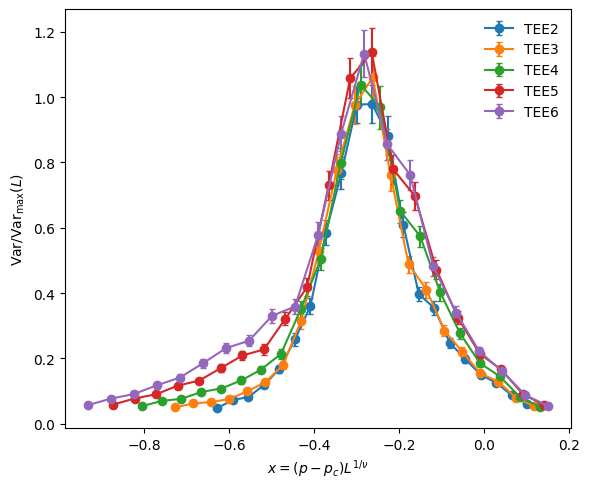

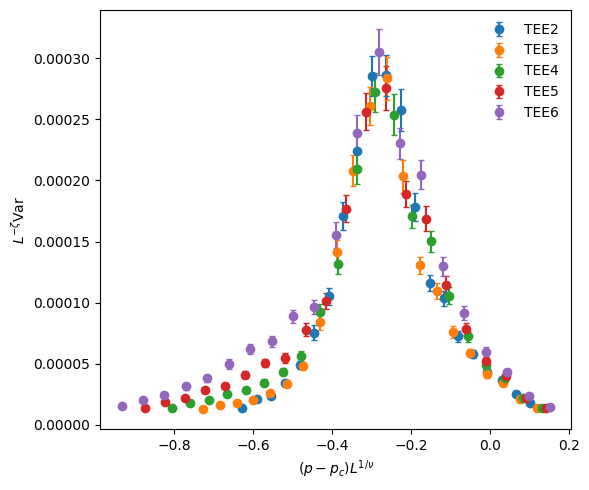


=== summary ===
TEE2: L_eff= 6.000 | g*≈0.797335 ± 0.00113 | Var_max≈0.00775977
TEE3: L_eff= 7.348 | g*≈0.805670 ± 0.00109 | Var_max≈0.0102894
TEE4: L_eff= 8.485 | g*≈0.811970 ± 0.00059 | Var_max≈0.0131253
TEE5: L_eff= 9.487 | g*≈0.817990 ± 0.00106 | Var_max≈0.0148793
TEE6: L_eff=10.392 | g*≈0.822092 ± 0.00092 | Var_max≈0.0195155
zeta=1.8300, pc=0.871990, nu=1.3850, window=(0.7710111533392885, 0.8510111533392886), S_window=2.0
[bootstrap] accepted 1975/2000 = 98.8% (skipped 25)
[bootstrap] pc=0.874179 ± 0.009108, nu=1.446315 ± 0.164191
[S compare] nu=1.3850: S=1.334e-10
[S compare] nu=4/3=1.3333: S=1.398e-10
[S ratio]   S(4/3)/S(1.3850) = 1.05


In [70]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

##########################################
#    code 2 (robust; rewritten)
##########################################

import re, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ===================== 設定 =====================
NPZ_PATH = "fss_merged.npz"

# 使う系列（存在しないキーは自動除外）
SERIES_KEYS = ["TEE2","TEE3","TEE4","TEE5","TEE6"]

# 有効面積 Ah → L = sqrt(Ah)
AH_MAP_NUM = {"TEE2":36, "TEE3":54, "TEE4":72, "TEE5":90, "TEE6":108}

# p 窓：AUTO で g* の平均±幅に合わせて作る。固定窓を使いたい場合は AUTO_PG_WINDOW=False にして PG_WINDOW を指定
AUTO_PG_WINDOW = True
PG_WINDOW      = (0.76, 0.86)   # AUTO=False のとき有効
AUTO_WIDTH_MIN = 0.04           # 自動窓の最小半幅（左右）

# ζ の扱い（ここは固定で検証しやすく）
ZETA_MODE  = "fixed"            # "fit" or "fixed"
ZETA_FIXED = 1.83

# g*→(pc,ν)：νを走査して線形回帰（安定化）
NU_SCAN = np.linspace(1.0, 2.2, 241)
# NU_SCAN = np.array([4/3])     # ← ν=4/3 固定で検証したいとき

# collapse の |x| 窓（図の表示・S評価の両方で使う）
S_WINDOW = 2.0

# 小サイズが暴れる時は一時除外
EXCLUDE_SERIES = set()          # 例: {"TEE2"}

RNG = np.random.default_rng(0)

# ===================== ユーティリティ =====================
def eff_size(keys):
    """L = sqrt(Ah)"""
    L=[]
    for k in keys:
        Ah = AH_MAP_NUM.get(k, None)
        if Ah is None:
            m=re.match(r"TEE(\d+)", k)
            L.append(float(m.group(1)) if m else np.nan)
        else:
            L.append(np.sqrt(float(Ah)))
    return np.asarray(L, float)

def resolve_err_key(prefix, dat):
    if f"{prefix}_var_err" in dat: return f"{prefix}_var_err"
    if f"{prefix}_err"     in dat: return f"{prefix}_err"
    raise KeyError(f"{prefix}: _var_err/_err がありません")

def quad(x,a,b,c): return a*x**2 + b*x + c

def peak_parabola(pg, y, dy):
    """
    近傍2～5点の2次フィット → 頂点 gx（±σ_gx）, 高さ yp（±minσ）
    フォールバック：グリッド最大
    """
    pg = np.asarray(pg, float); y = np.asarray(y, float); dy = np.asarray(dy, float)
    eps = max(1e-12, np.nanmedian(np.abs(y))*1e-6 if np.isfinite(y).any() else 1e-8)
    dy = np.where(np.isfinite(dy)&(dy>0), dy, eps)
    imax = int(np.nanargmax(y))
    lo,hi = max(0,imax-2), min(len(pg), imax+3)
    x, yy, dyy = pg[lo:hi], y[lo:hi], dy[lo:hi]
    if x.size < 3:
        gx = float(pg[imax]); gx_err = (pg[min(imax+1,len(pg)-1)]-pg[max(imax-1,0)]) / np.sqrt(12)
        yp = float(y[imax]);  yp_err = float(dy[imax])
        return gx, gx_err, max(yp,1e-16), max(yp_err,1e-12)
    try:
        popt, pcov = curve_fit(quad, x, yy, sigma=dyy, absolute_sigma=True, maxfev=20000)
        a,b,c = popt
        gx = -b/(2*a)
        vb, va, vab = pcov[1,1], pcov[0,0], pcov[0,1]
        dg_db = -1/(2*a); dg_da =  b/(2*a*a)
        vg = dg_db**2 * vb + dg_da**2 * va + 2*dg_db*dg_da*vab
        gx_err = float(np.sqrt(abs(vg))) if np.isfinite(vg) and vg>0 else (x.ptp()/np.sqrt(12))
        yp = float(quad(gx, *popt))
        if (gx < pg.min()) or (gx > pg.max()):
            gx = float(pg[imax]); gx_err = (pg[min(imax+1,len(pg)-1)]-pg[max(imax-1,0)]) / np.sqrt(12)
            yp = float(y[imax]);  yp_err = float(dy[imax])
            return gx, gx_err, max(yp,1e-16), max(yp_err,1e-12)
        yp_err = float(np.nanmin(dyy)) if np.isfinite(dyy).any() else eps
        return float(gx), max(gx_err,1e-6), max(yp,1e-16), max(yp_err,1e-12)
    except Exception:
        gx = float(pg[imax]); gx_err = (pg[min(imax+1,len(pg)-1)]-pg[max(imax-1,0)]) / np.sqrt(12)
        yp = float(y[imax]);  yp_err = float(dy[imax])
        return gx, gx_err, max(yp,1e-16), max(yp_err,1e-12)

def fit_pc_nu_by_scan(L_eff, gmu, gse, nu_grid, pc_lo=None, pc_hi=None, pg=None):
    """
    各 ν で X=L^{-1/ν},  y=g* を w=1/σ^2 で線形回帰: y = pc + a X。
    χ^2/N を最小にする (pc, ν) を返す。誤差に p の刻みフロア dp/√12 を合成。
    """
    L_eff = np.asarray(L_eff, float)
    y  = np.asarray(gmu, float)
    dy = np.asarray(gse, float)

    # p の量子化誤差を合成（過小評価対策）
    if pg is not None and pg.size >= 2:
        dp = float(np.median(np.diff(np.sort(pg))))
        dy = np.sqrt(dy**2 + (dp/np.sqrt(12))**2)

    w  = 1.0/np.maximum(dy, np.nanmedian(np.abs(dy))*1e-6 + 1e-8)**2

    best = (np.inf, None, None)  # (chi2_per_pt, pc, nu)
    for nu_try in nu_grid:
        X = L_eff**(-1.0/nu_try)
        A = np.vstack([np.ones_like(X), X]).T
        W = np.diag(w)
        ATA = A.T @ W @ A
        ATy = A.T @ W @ y
        try:
            beta = np.linalg.solve(ATA, ATy)   # beta[0]=pc, beta[1]=a
        except np.linalg.LinAlgError:
            continue
        pc_try = float(beta[0])
        if (pc_lo is not None and pc_try < pc_lo) or (pc_hi is not None and pc_try > pc_hi):
            continue
        yfit = A @ beta
        chi2 = np.sum(w * (y - yfit)**2)
        dof  = max(1, (len(y)-2))
        chi2_per = chi2 / dof
        if chi2_per < best[0] and np.isfinite(chi2_per):
            best = (chi2_per, pc_try, float(nu_try))
    return best  # (chi2_per_pt, pc, nu)

def collapse_score(pc, nu, zeta, series_used, L_eff, Y_all, pg, s_window=None, min_series_per_bin=2):
    """
    y/L^zeta vs x=(p-pc)L^{1/nu} を補間。各グリッド点で有効系列数>=min_series_per_bin のところだけで
    重み付き分散の平均をスコアにする。
    ※ 各系列の x 範囲外は重みを 0 にする（外挿重みの漏れを防ぐ）
    """
    per = []
    glob_xmin, glob_xmax = -np.inf, np.inf  # 交差領域
    for s, Le in zip(series_used, L_eff):
        p, y, dy = Y_all[s]
        x = (p - pc) * (Le**(1.0/nu))
        yy = y / (Le**zeta)
        dyy = dy / (Le**zeta)
        base = np.nanmedian(np.abs(yy)) if np.isfinite(yy).any() else 1.0
        w = 1.0/np.maximum(dyy, base*1e-6 + 1e-8)**2
        if s_window is not None:
            m = np.abs(x) < s_window
            x, yy, w = x[m], yy[m], w[m]
        if x.size < 3:
            continue
        glob_xmin = max(glob_xmin, float(x.min()))
        glob_xmax = min(glob_xmax, float(x.max()))
        per.append((x, yy, w))

    if len(per) < 2 or not np.isfinite(glob_xmin) or not np.isfinite(glob_xmax) or glob_xmax <= glob_xmin:
        return np.inf

    grid = np.linspace(glob_xmin, glob_xmax, 200)
    Ygrid, Wgrid = [], []
    for (x, yy, w) in per:
        yg = np.interp(grid, x, yy)
        wg = np.interp(grid, x, w)
        mask_in = (grid >= x.min()) & (grid <= x.max())
        wg = wg * mask_in.astype(float)
        Ygrid.append(yg); Wgrid.append(wg)

    Ygrid = np.stack(Ygrid, 0)
    Wgrid = np.stack(Wgrid, 0)

    n_eff = (Wgrid > 0).sum(axis=0)
    valid = n_eff >= min_series_per_bin
    if not np.any(valid):
        return np.inf

    Yg = Ygrid[:, valid]
    Wg = Wgrid[:, valid]

    wsum = Wg.sum(axis=0) + 1e-12
    ybar = (Wg * Yg).sum(axis=0) / wsum
    Svec = (Wg * (Yg - ybar)**2).sum(axis=0) / wsum
    S = float(np.mean(Svec))
    return S

def bootstrap_pc_nu(L_eff, gmu, gse, nu_grid, pc_lo, pc_hi, pg=None, nboot=2000, rng=None):
    """
    g*_L ~ N(mu_L, se_L) を再サンプルし、毎回 fit_pc_nu_by_scan で (pc,nu) を推定。
    失敗サンプルはスキップ。受理率と平均±標準偏差を返す。
    """
    import numpy as np
    if rng is None:
        rng = np.random.default_rng(0)

    # 量子化誤差を合成
    if pg is not None and len(pg) >= 2:
        dp = float(np.median(np.diff(np.sort(pg))))
    else:
        dp = 0.0
    gse_eff = np.sqrt(np.asarray(gse, float)**2 + (dp/np.sqrt(12))**2)

    # pc の探索帯を少し広げる（外れ値対策）
    pc_lo_exp = float(pc_lo) - 0.01
    pc_hi_exp = float(pc_hi) + 0.01

    pcs, nus = [], []
    n_fail = 0
    for _ in range(nboot):
        g_samp = rng.normal(np.asarray(gmu, float), gse_eff)
        chi2per, pc_try, nu_try = fit_pc_nu_by_scan(
            L_eff, g_samp, gse_eff, nu_grid,
            pc_lo=pc_lo_exp, pc_hi=pc_hi_exp, pg=pg
        )
        if (pc_try is None) or (nu_try is None) or not (np.isfinite(pc_try) and np.isfinite(nu_try)):
            n_fail += 1
            continue
        pcs.append(pc_try); nus.append(nu_try)

    pcs = np.asarray(pcs, float)
    nus = np.asarray(nus, float)
    n_acc = pcs.size
    acc_rate = n_acc / float(nboot)
    print(f"[bootstrap] accepted {n_acc}/{nboot} = {acc_rate:.1%} (skipped {n_fail})")

    min_needed = max(30, int(0.05*nboot))
    if n_acc < min_needed:
        raise RuntimeError(f"bootstrap accepted only {n_acc} samples (<{min_needed}). "
                           "Try widening pc bounds or increasing nboot.")

    pc_mu = float(np.nanmean(pcs))
    pc_se = float(np.nanstd(pcs, ddof=1))
    nu_mu = float(np.nanmean(nus))
    nu_se = float(np.nanstd(nus, ddof=1))
    return pc_mu, pc_se, nu_mu, nu_se

# ===================== 1) 読み込み & series 検出 =====================
dat = np.load(NPZ_PATH, allow_pickle=True)
pg = np.asarray(dat["pg"], float)
if np.nanmedian(pg) > 1.5:
    print("[warn] pg appears percent-like -> divide by 100.")
    pg = pg / 100.0

all_series = sorted({ m.group(1) for k in dat.keys()
                      for m in [re.match(r'^(TEE\d+)_', k)] if m })
SERIES_KEYS = [s for s in SERIES_KEYS if (s in all_series) and (s not in EXCLUDE_SERIES)]
if not SERIES_KEYS:
    raise RuntimeError("有効な SERIES_KEYS がありません")

# ===================== 2) 粗い g* 推定（全域）→ 自動窓 =====================
gstar_rough = []
for s in SERIES_KEYS:
    ykey = f"{s}_var"; dykey = resolve_err_key(s, dat)
    y  = np.asarray(dat[ykey],  float)
    dy = np.asarray(dat[dykey], float)
    gx, gx_se, yp, yp_se = peak_parabola(pg, y, dy)
    gstar_rough.append(gx)
gstar_rough = np.asarray(gstar_rough, float)

if AUTO_PG_WINDOW:
    pc0 = float(np.mean(gstar_rough))
    dpg = max(AUTO_WIDTH_MIN, float(np.std(gstar_rough) + 0.02))
    PG_WINDOW = (pc0 - dpg, pc0 + dpg)
print(f"[info] PG_WINDOW = {PG_WINDOW}")

# ===================== 3) 窓内で g* とピーク高さの再推定 =====================
gstar_mu, gstar_se, Vmax, Vmax_se, used = [], [], [], [], []
Y_all = {}
mask_win = (pg >= PG_WINDOW[0]) & (pg <= PG_WINDOW[1])
for s in SERIES_KEYS:
    ykey = f"{s}_var"; dykey = resolve_err_key(s, dat)
    y  = np.asarray(dat[ykey],  float)
    dy = np.asarray(dat[dykey], float)
    if y.shape != pg.shape:
        print(f"[skip] {s}: shape mismatch"); continue
    gg, yy, ddy = (pg[mask_win], y[mask_win], dy[mask_win]) if mask_win.sum()>=3 else (pg,y,dy)
    gx, gx_se, yp, yp_se = peak_parabola(gg, yy, ddy)
    gstar_mu.append(gx); gstar_se.append(gx_se)
    Vmax.append(yp);     Vmax_se.append(yp_se)
    used.append(s)
    # collapse 用（全域を保持。評価は collapse_score 側で |x|窓＆交差領域に限定）
    Y_all[s] = (pg, y, dy)

gstar_mu = np.array(gstar_mu, float)
gstar_se = np.array(gstar_se, float)
Vmax     = np.array(Vmax,     float)
Vmax_se  = np.array(Vmax_se,  float)
L_eff    = eff_size(used)

# ===================== 4) ζ 推定（or 固定） =====================
if ZETA_MODE == "fixed":
    zeta = float(ZETA_FIXED)
else:
    m = (Vmax>0)&np.isfinite(Vmax)&np.isfinite(L_eff)
    if m.sum()<2: raise RuntimeError("ζ 回帰に十分な点がありません")
    zeta = np.polyfit(np.log(L_eff[m]), np.log(Vmax[m]), 1)[0]
print(f"[info] zeta = {zeta:.4f}  (mode={ZETA_MODE})")

# ===================== 5) pc, ν：ν走査＋線形回帰 =====================
pc_lo = float(np.max(gstar_mu) - 0.005)
pc_hi = float(np.max(gstar_mu) + 0.050)

chi2per, pc_scan, nu_scan = fit_pc_nu_by_scan(L_eff, gstar_mu, gstar_se, NU_SCAN,
                                              pc_lo=pc_lo, pc_hi=pc_hi, pg=pg)
pc, nu = pc_scan, nu_scan
print(f"[scan-fit]  pc={pc:.6f}, nu={nu:.4f}, chi2/pt={chi2per:.4f}")

# ===================== 6) 非-pyfssaスコア（交差領域限定） =====================
S = collapse_score(pc, nu=nu, zeta=zeta,
                   series_used=used, L_eff=L_eff, Y_all=Y_all, pg=pg,
                   s_window=S_WINDOW, min_series_per_bin=2)

# 有効系列数の診断
def count_effective_series(pc, nu, zeta, series_used, L_eff, Y_all, s_window):
    xs_min, xs_max = -np.inf, np.inf
    per = []
    for s, Le in zip(series_used, L_eff):
        p, y, dy = Y_all[s]
        x = (p - pc) * (Le**(1.0/nu))
        if s_window is not None:
            m = np.abs(x) < s_window
            x = x[m]
        if x.size < 3: 
            continue
        xs_min = max(xs_min, float(x.min()))
        xs_max = min(xs_max, float(x.max()))
        per.append((x.min(), x.max()))
    if xs_max <= xs_min or len(per) < 2:
        return 0, 0
    grid = np.linspace(xs_min, xs_max, 200)
    n_eff = np.zeros_like(grid, dtype=int)
    for xmin, xmax in per:
        n_eff += ((grid >= xmin) & (grid <= xmax)).astype(int)
    return int(n_eff.min()), int(n_eff.max())

nmin, nmax = count_effective_series(pc, nu, zeta, used, L_eff, Y_all, S_WINDOW)
print(f"[diagnostics] effective series per-bin: min={nmin}, max={nmax}")
print(f"[collapse score (non-pyfssa)] S={S:.3e}")

# ===================== 7) コラプス図 =====================
# (A) ピーク正規化（ζフリー）
plt.figure(figsize=(6,5))
for s, Le, gx, V in zip(used, L_eff, gstar_mu, Vmax):
    p, y, dy = Y_all[s]
    x = (p - pc) * (Le**(1.0/nu))
    m = np.abs(x) < S_WINDOW
    p, y, dy, x = p[m], y[m], dy[m], x[m]
    yN, dyN = y/max(V,1e-16), dy/max(V,1e-16)
    plt.errorbar(x, yN, yerr=dyN, fmt='o-', capsize=2, label=s)
plt.xlabel(r"$x=(p-p_c)L^{1/\nu}$")
plt.ylabel(r"$\mathrm{Var}/\mathrm{Var}_{\max}(L)$")
plt.legend(frameon=False); plt.tight_layout()
plt.savefig("collapse_np_peaknorm.png", dpi=300, bbox_inches="tight"); plt.show()

# (B) ζ使用（本番）
plt.figure(figsize=(6,5))
for s, Le in zip(used, L_eff):
    p, y, dy = Y_all[s]
    x = (p - pc) * (Le**(1.0/nu))
    m = np.abs(x) < S_WINDOW
    p, y, dy, x = p[m], y[m], dy[m], x[m]
    yB, dyB = y/(Le**zeta), dy/(Le**zeta)
    plt.errorbar(x, yB, yerr=dyB, fmt='o', capsize=2, label=s)
plt.xlabel(r"$(p-p_c)L^{1/\nu}$")
plt.ylabel(r"$L^{-\zeta}\mathrm{Var}$")
plt.legend(frameon=False); plt.tight_layout()
plt.savefig("collapse_np_powerlaw.png", dpi=300, bbox_inches="tight"); plt.show()

# ===================== 8) サマリ =====================
print("\n=== summary ===")
for s, Le, gx, gse, V in zip(used, L_eff, gstar_mu, gstar_se, Vmax):
    print(f"{s:>4s}: L_eff={Le:6.3f} | g*≈{gx:.6f} ± {gse:.5f} | Var_max≈{V:.6g}")
print(f"zeta={zeta:.4f}, pc={pc:.6f}, nu={nu:.4f}, window={PG_WINDOW}, S_window={S_WINDOW}")

# ===================== 9) ブートストラップ誤差（pc, nu） =====================
nu_grid = np.linspace(1.2, 1.6, 401)  # νの探索帯（必要に応じて調整）
pc_mu, pc_se, nu_mu, nu_se = bootstrap_pc_nu(
    L_eff, gstar_mu, gstar_se, nu_grid,
    pc_lo=float(np.max(gstar_mu)-0.005),
    pc_hi=float(np.max(gstar_mu)+0.050),
    pg=pg, nboot=2000, rng=RNG
)
print(f"[bootstrap] pc={pc_mu:.6f} ± {pc_se:.6f}, nu={nu_mu:.6f} ± {nu_se:.6f}")

# ===================== 10) ν=4/3 と S 比較 =====================
S_nu1333 = collapse_score(pc, nu=4/3, zeta=zeta,
                          series_used=used, L_eff=L_eff, Y_all=Y_all, pg=pg,
                          s_window=S_WINDOW, min_series_per_bin=2)
print(f"[S compare] nu={nu:.4f}: S={S:.3e}")
print(f"[S compare] nu=4/3=1.3333: S={S_nu1333:.3e}")
print(f"[S ratio]   S(4/3)/S({nu:.4f}) = {S_nu1333 / S if S>0 else np.inf:.3g}")
